# Local Group SBI notebook: from pair catalogue to posterior

This notebook takes the output **after pair finding and pair-level filtering** and turns it into an SBI result for

$$
p(\theta \mid x_{\text{obs}},\, S)
$$

| Symbol | Meaning |
|--------|---------|
| $\theta$ | Hidden quantity to infer, e.g. total dark-matter mass |
| $x_{\text{obs}}$ | Observed constraint vector, e.g. separation, radial velocity, tangential velocity |
| $S$ | Analogue-selection pipeline that produced the final catalogue of candidate Local Group pairs |

---

## Important distinction: "the simulation" vs "simulation-based inference"

There are two different uses of the word **simulation** here:

1. **The cosmological simulation dataset**  
   The large TNG-like dataset. Source of the galaxies and halos, and therefore the source of the candidate pairs.

2. **Simulation-based inference (SBI)**  
   In SBI papers, a "simulator" means a forward model that maps parameters $\theta$ to observables $x$.  
   Here we do **catalogue-based SBI** instead: the pair catalogue is precomputed, and each row already contains both a feature vector $x_i$ and a hidden target $\theta_i$.  
   The notebook learns the $x \to \theta$ relationship from the catalogue, then evaluates it at the chosen observation $x_{\text{obs}}$.

---

## What to edit most often

The main edit point is the **feature configuration cell** below:

| What | Where |
|------|-------|
| Which features enter the model | `ACTIVE_FEATURES` |
| Observed values for each feature | `FEATURE_INFO` |
| Target quantity | `TARGET` |

This makes it straightforward to test different observational constraint sets without touching the rest of the notebook.


## 1) Load data, build candidate pairs, and apply the analogue-selection pipeline

This section is still the "data preparation" part of the workflow:

raw simulation -> filtered objects -> candidate pairs -> final analogue catalogue

The final catalogue defines the empirical joint sample $(\theta, x_i)$. that SBI will learn from.


In [1]:

import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import illustris_python as il

# Ensure we can import helper modules from several likely locations.
repo_root = Path.cwd().parent
candidate_paths = [
    repo_root / "scripts",
    Path.cwd(),
    Path("/mnt/data"),
    repo_root / "illustris_python",
]
for p in candidate_paths:
    if p.exists():
        sys.path.insert(0, str(p))

import lg_analogues as lg

# Try the user's project module first, then fall back to the helper file.
try:
    from lg_abc import build_pair_catalog
except ImportError:
    try:
        from lg_abc_updated import build_pair_catalog
    except ImportError as exc:
        raise ImportError(
            "Could not import build_pair_catalog. Place lg_abc.py (or lg_abc_updated.py) in scripts/ or the notebook folder."
        ) from exc

from lg_sbi import (
    prepare_sbi_problem,
    fit_catalog_npe,
    infer_with_npe,
    plot_sbi_theta_posterior,
    plot_sbc_rank_hist,
    plot_expected_coverage,
)

print("lg_analogues:", lg.__file__)

# Data paths and fields
basePath = os.path.expanduser("~/Documents/uni/dsp/tng300/outputs")
snap = 99

subhalo_fields = [
    "SubhaloPos",
    "SubhaloVel",
    "SubhaloMassType",
    "SubhaloSFRinRad",
    "SubhaloFlag",
    "SubhaloGrNr",
]

sub = il.groupcat.loadSubhalos(basePath, snap, fields=subhalo_fields)
header_consts = lg.load_header_constants(basePath, snap)
h = header_consts["h"]
box_ckpch = header_consts["box_ckpch"]

print("Loaded subhalos:", sub["count"])
print("h:", h, "box_ckpch:", box_ckpch)

# Selection S: central + largest satellite in stellar-mass window
mstar_min = 2e10
mstar_max = 5e11

sample = lg.select_central_plus_largest_satellite_by_stellar_mass(
    sub=sub,
    basePath=basePath,
    snap=snap,
    h=h,
    mstar_min=mstar_min,
    mstar_max=mstar_max,
)

print("Selected objects:", sample.keep_idx.size)

# Pair finding in separation window
r_min_kpc = 500.0
r_max_kpc = 1000.0

pair_set = lg.find_pairs_periodic(
    pos=sample.pos,
    vel=sample.vel,
    grnr=sample.grnr,
    h=h,
    box_ckpch=box_ckpch,
    r_min_kpc=r_min_kpc,
    r_max_kpc=r_max_kpc,
)

print("Pairs before filtering:", pair_set.i.size)
print("same-host pairs:", int(np.sum(pair_set.same_host)))
print("different-host pairs:", int(np.sum(~pair_set.same_host)))

# Pipeline filters: isolation (no third object with M* >= x * max(M*_pair) in relevant FoF group(s))
pipeline = lg.AnaloguePipeline(pair_set)

isolation_x = 1.5
iso_mask = lg.isolation_filter_no_third_factor_x_in_same_group(
    sub=sub,
    pair_i=pipeline.pairs.i,
    pair_j=pipeline.pairs.j,
    sample_grnr=sample.grnr,
    sample_keep_idx_global=sample.keep_idx,
    h=h,
    x=isolation_x,
)
pipeline.apply_filter(f"isolation_x{isolation_x}", iso_mask)

pipeline.print_cutflow()
cutflow = pipeline.get_cutflow()
cutflow


lg_analogues: /home/tp/Documents/uni/dsp/scripts/lg_analogues.py
Loaded subhalos: 14485709
h: 0.6774 box_ckpch: 205000.0
Selected objects: 45392
Pairs before filtering: 2655
same-host pairs: 2084
different-host pairs: 571
initial: 2655 pairs remaining
isolation_x1.5: 2601 pairs remaining


[{'label': 'initial', 'before': 2655, 'after': 2655, 'frac_kept': 1.0},
 {'label': 'isolation_x1.5',
  'before': 2655,
  'after': 2601,
  'frac_kept': 0.9796610169491525}]


## 2) Choose the feature set and define the observed system $x_{obs}$

This is the easiest cell to edit.

### How to use it
- `FEATURE_INFO` stores metadata for each possible feature:
  - observed value
  - plot label
  - short explanation
- `ACTIVE_FEATURES` chooses which features are used in the SBI model
- `TARGET` chooses the hidden quantity to infer

The order of `ACTIVE_FEATURES` is the order used in the feature matrix \(X\) and in the observation vector \(x_{obs}\).

### Why this matters
Changing `x_obs` means you are asking about a **different observed Local Group-like system**.

Changing `ACTIVE_FEATURES` means you are changing **which observational constraints** the model conditions on.

That is the key scientific question: how does the posterior over hidden properties change when the observational constraints change?


In [2]:

# ----------------------------
# User-editable feature config
# ----------------------------

FEATURE_INFO = {
    "r_kpc": {
        "obs": 770.0,
        "label": "Pair separation r [kpc]",
        "description": "Current MW-M31 separation proxy.",
    },
    "v_r": {
        "obs": -109.0,
        "label": "Radial velocity v_r [km/s]",
        "description": "Relative radial velocity of the pair.",
    },
    "v_t": {
        "obs": 17.0,
        "label": "Tangential velocity v_t [km/s]",
        "description": "Relative tangential velocity of the pair.",
    },
    # Optional examples if your catalogue contains these fields:
    # "mstar_sum": {"obs": 1.1e11, "label": "Total stellar mass [Msun]", "description": "Optional stellar-mass constraint."},
    # "ssfr_i": {"obs": 0.02, "label": "Primary sSFR [1/Gyr]", "description": "Optional morphology / star-formation proxy."},
}

ACTIVE_FEATURES = ["r_kpc", "v_r", "v_t"]

# Hidden quantity to infer.
TARGET = "mdm_sum"
TARGET_LOG10 = True

# Optional extra transforms
LOG10_FEATURES = set()

# Override values here instead of editing FEATURE_INFO directly, if preferred.
X_OBS_OVERRIDE = {
    # "v_t": 30.0,
}

# NPE training controls
SBI_CONFIG = {
    "density_model": "nsf",
    "hidden_features": 64,
    "num_transforms": 5,
    "training_batch_size": 128,
    "learning_rate": 5e-4,
    "validation_fraction": 0.1,
    "calibration_fraction": 0.15,
    "stop_after_epochs": 30,
    "max_num_epochs": 300,
    "random_state": 0,
    "show_train_summary": False,
}

def build_x_obs(active_features, feature_info, overrides=None):
    overrides = {} if overrides is None else dict(overrides)
    values = []
    for name in active_features:
        if name not in feature_info:
            raise KeyError(f"Feature '{name}' is missing from FEATURE_INFO")
        value = overrides.get(name, feature_info[name]["obs"])
        values.append(float(value))
    return np.asarray(values, dtype=float)

x_obs = build_x_obs(ACTIVE_FEATURES, FEATURE_INFO, X_OBS_OVERRIDE)

feature_table = pd.DataFrame({
    "feature": ACTIVE_FEATURES,
    "observed_value": [X_OBS_OVERRIDE.get(name, FEATURE_INFO[name]["obs"]) for name in ACTIVE_FEATURES],
    "label": [FEATURE_INFO[name]["label"] for name in ACTIVE_FEATURES],
    "description": [FEATURE_INFO[name]["description"] for name in ACTIVE_FEATURES],
})

display(feature_table)
print("x_obs =", x_obs)
print("Target =", TARGET, "| target_log10 =", TARGET_LOG10)


,feature,observed_value,label,description
0,r_kpc,770.0,Pair separation r [kpc],Current MW-M31 separation proxy.
1,v_r,-109.0,Radial velocity v_r [km/s],Relative radial velocity of the pair.
2,v_t,17.0,Tangential velocity v_t [km/s],Relative tangential velocity of the pair.


x_obs = [ 770. -109.   17.]
Target = mdm_sum | target_log10 = True


## 3) Build the final analogue catalogue and the SBI training table

At this point, the notebook turns the final selected pairs into a table with two roles:

- **features** $X$: the observed-like quantities we condition on
- **target** $\theta$: the hidden quantity we want a posterior for

This is the key conceptual step.  
Each row is one simulated analogue pair. That row already contains both $x_i$ and $\theta_i$, so the catalogue can be treated as an empirical sample from the joint distribution $p(\theta, x \mid S)$.

In [3]:

cat = build_pair_catalog(
    sample=sample,
    pairs=pipeline.pairs,
    sub=sub,
    sfr_field="SubhaloSFRinRad",
)

sbi_problem = prepare_sbi_problem(
    catalog=cat,
    features=ACTIVE_FEATURES,
    target=TARGET,
    log10_features=LOG10_FEATURES,
    target_log10=TARGET_LOG10,
)

X = sbi_problem["X"]
theta = sbi_problem["theta"]

print("Pairs after cuts:", X.shape[0])
print("Number of active features:", X.shape[1])
print("Dropped non-finite rows:", sbi_problem["dropped_rows"])

theta_summary = {
    "mean": float(np.mean(theta)),
    "median": float(np.quantile(theta, 0.5)),
    "q16": float(np.quantile(theta, 0.16)),
    "q84": float(np.quantile(theta, 0.84)),
}
theta_summary


Pairs after cuts: 2601
Number of active features: 3
Dropped non-finite rows: 0


{'mean': 12.869573375815015,
 'median': 12.799379590308819,
 'q16': 12.48133700180316,
 'q84': 13.305573548282817}


## 4) Quick sanity plots before training SBI

These plots answer two basic questions:

1. **Is the observed system inside the support of the analogue catalogue?**  
   If not, the model would be forced to extrapolate.

2. **Which features look typical or atypical before any conditional inference?**  
   This helps explain which observables will likely drive the posterior.


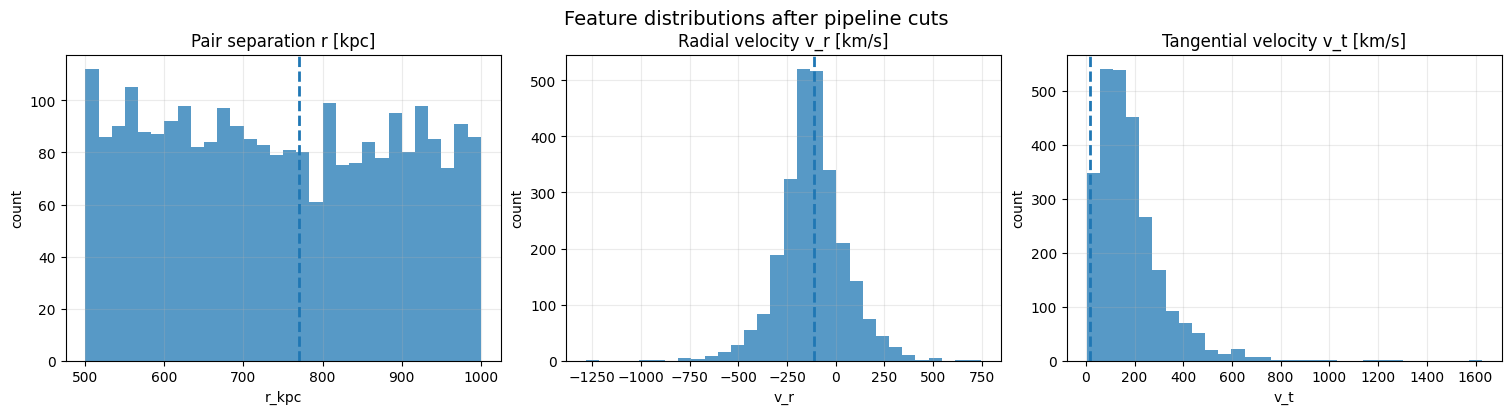

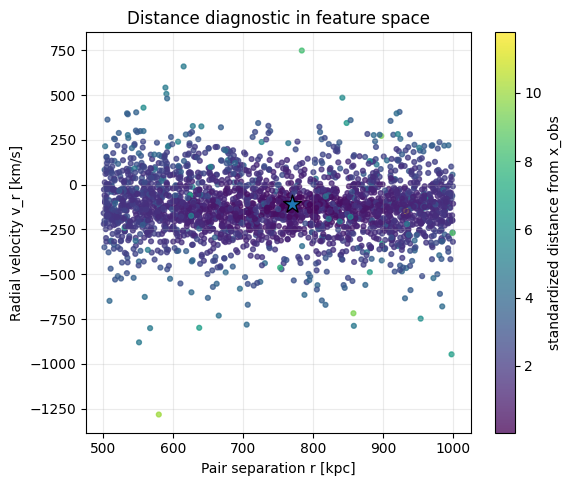

In [4]:

n_features = len(ACTIVE_FEATURES)
fig, axes = plt.subplots(1, n_features, figsize=(5 * n_features, 3.8), constrained_layout=True)
if n_features == 1:
    axes = [axes]

for j, name in enumerate(ACTIVE_FEATURES):
    ax = axes[j]
    ax.hist(X[:, j], bins=30, alpha=0.75)
    ax.axvline(x_obs[j], linestyle="--", linewidth=2)
    ax.set_title(FEATURE_INFO[name]["label"])
    ax.set_xlabel(name)
    ax.set_ylabel("count")
    ax.grid(alpha=0.25)

fig.suptitle("Feature distributions after pipeline cuts", y=1.05, fontsize=14)
plt.show()

# Optional 2D view of the first two active features.
if len(ACTIVE_FEATURES) >= 2:
    z = (X - x_obs[None, :]) / np.where(np.std(X, axis=0) > 0.0, np.std(X, axis=0), 1.0)
    d = np.sqrt(np.sum(z * z, axis=1))

    fig, ax = plt.subplots(figsize=(6.2, 5.2))
    sc = ax.scatter(X[:, 0], X[:, 1], c=d, s=12, alpha=0.75)
    ax.scatter([x_obs[0]], [x_obs[1]], marker="*", s=180, edgecolor="k", linewidth=1.0)
    ax.set_xlabel(FEATURE_INFO[ACTIVE_FEATURES[0]]["label"])
    ax.set_ylabel(FEATURE_INFO[ACTIVE_FEATURES[1]]["label"])
    ax.set_title("Distance diagnostic in feature space")
    cb = plt.colorbar(sc, ax=ax)
    cb.set_label("standardized distance from x_obs")
    ax.grid(alpha=0.25)
    plt.show()



## 5) Fit the NPE model

This uses **Neural Posterior Estimation (NPE)** with a normalizing flow.

### What the model learns
The network learns a conditional density

$
q_\phi(\theta \mid x)
$

from the pair catalogue rows. After training, we can evaluate that learned posterior at the chosen observation $x_{obs}$.

### Why there is no `sigma` here
In ABC or KDE, you usually set a tolerance or bandwidth by hand.

In NPE, there is no ABC-style `sigma` in the posterior itself.  
Instead, the network learns the relationship between \(x\) and \(\theta\) directly from the catalogue.

That means:
- `x_obs` still matters because it is the query point
- but there is no manually chosen distance tolerance in the same role as ABC


In [5]:

# If needed in a fresh environment:
# %pip install sbi

fit = fit_catalog_npe(
    X=X,
    theta=theta,
    x_obs=x_obs,
    feature_names=sbi_problem["feature_names"],
    target_name=sbi_problem["target_name"],
    **SBI_CONFIG,
)

print("Training config:")
display(pd.DataFrame([fit["training_config"]]))

print("Held-out diagnostics:")
diag = fit["diagnostics"].copy()
diag.pop("sbc_ranks", None)  # large array, show separately below
display(diag)


/home/tp/Documents/uni/dsp/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


 Neural network successfully converged after 58 epochs.

100%|██████████| 500/500 [00:00<00:00, 25126.43it/s]


Training config:


,density_model,hidden_features,num_transforms,training_batch_size,learning_rate,validation_fraction,calibration_fraction,stop_after_epochs,max_num_epochs,device
0,nsf,64,5,128,0.0005,0.1,0.15,30,300,cpu


Held-out diagnostics:


{'calibration_size': 390,
 'train_size': 2211,
 'mean_calibration_log_prob': -0.18122342282380813,
 'sbc_summary': {'num_eval': 50,
  'num_posterior_samples': 200,
  'mean_rank_fraction': array([0.4548]),
  'std_rank_fraction': array([0.25644095])},
 'expected_coverage_1d': {'num_eval': 50,
  'num_posterior_samples': 500,
  'levels': array([0.5, 0.8, 0.9]),
  'empirical': array([0.52, 0.92, 0.98])},
 'x_obs_support_check': {'outside_range': array([False, False, False]),
  'n_outside': 0,
  'feature_min': array([  500.37124634, -1282.8807373 ,     3.00650334]),
  'feature_max': array([ 999.9911499 ,  748.37384033, 1626.0802002 ]),
  'nearest_distance': 0.04018945501151344,
  'nearest_index': 1730,
  'nearest_x': array([ 767.43780518, -109.74478149,   21.93921471])}}


## 6) Evaluate the posterior at the chosen observation \(x_{obs}\)

This produces the scientific end result:

$
p(\theta \mid x_{obs}, S)
$

In plain language:

> Given the observed Local Group-like features and given the analogue-selection pipeline, what values of the hidden quantity $\theta$ are plausible?


In [6]:

sbi_result = infer_with_npe(
    fit,
    x_obs=x_obs,
    num_samples=20_000,
    random_state=SBI_CONFIG["random_state"],
    ppc_draws=500,
    ppc_neighbors=25,
)

sbi_result["summary"]


100%|██████████| 20000/20000 [00:00<00:00, 155680.75it/s]


{'mean': 12.502141312837601,
 'median': 12.448736667633057,
 'q16': 12.333050155639649,
 'q84': 12.62695514678955}

In [7]:

summary = sbi_result["summary"]
print("Posterior summary for", TARGET)
print(summary)

if TARGET_LOG10:
    median_lin = 10 ** summary["median"]
    q16_lin = 10 ** summary["q16"]
    q84_lin = 10 ** summary["q84"]
    print()
    print("Approximate linear-scale interpretation:")
    print(f"median  = {median_lin:.3e}")
    print(f"q16     = {q16_lin:.3e}")
    print(f"q84     = {q84_lin:.3e}")

print()
print("Support check:")
display(pd.DataFrame([{
    "n_outside": sbi_result["support_check"]["n_outside"],
    "nearest_distance": sbi_result["support_check"]["nearest_distance"],
    "nearest_index": sbi_result["support_check"]["nearest_index"],
}]))

nearest_x_df = pd.DataFrame({
    "feature": ACTIVE_FEATURES,
    "x_obs": x_obs,
    "nearest_simulated_x": sbi_result["support_check"]["nearest_x"],
    "feature_min": sbi_result["support_check"]["feature_min"],
    "feature_max": sbi_result["support_check"]["feature_max"],
    "outside_range": sbi_result["support_check"]["outside_range"],
})
display(nearest_x_df)


Posterior summary for mdm_sum
{'mean': 12.502141312837601, 'median': 12.448736667633057, 'q16': 12.333050155639649, 'q84': 12.62695514678955}

Approximate linear-scale interpretation:
median  = 2.810e+12
q16     = 2.153e+12
q84     = 4.236e+12

Support check:


,n_outside,nearest_distance,nearest_index
0,0,0.040189,1730


,feature,x_obs,nearest_simulated_x,feature_min,feature_max,outside_range
0,r_kpc,770.0,767.437805,500.371246,999.99115,False
1,v_r,-109.0,-109.744781,-1282.880737,748.37384,False
2,v_t,17.0,21.939215,3.006503,1626.08020,False



## 7) Posterior plots

These are the main visual outputs to show in a presentation:

1. **Prior vs posterior for $\theta$**  
   Did the observation actually sharpen or shift the distribution?

2. **Approximate posterior predictive check in feature space**  
   Do feature values associated with posterior-supported $\theta$ look consistent with the observation?

3. **Training diagnostics**  
   Are the held-out calibration checks roughly reasonable?


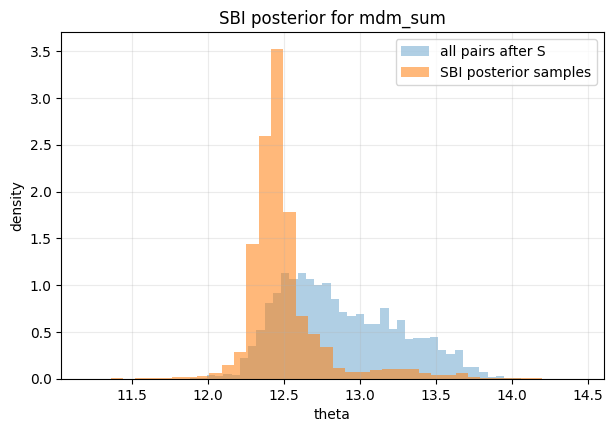

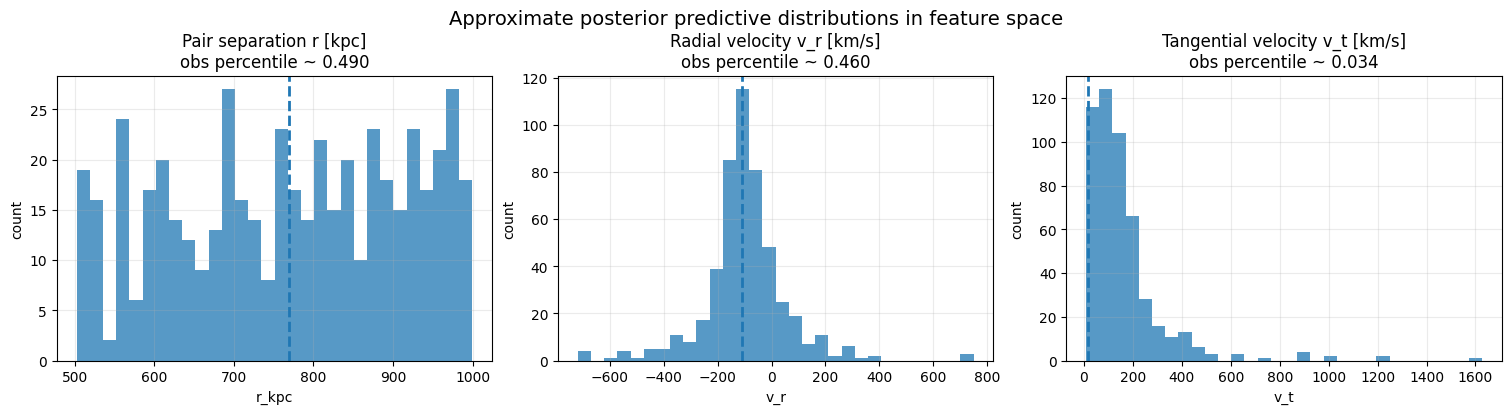

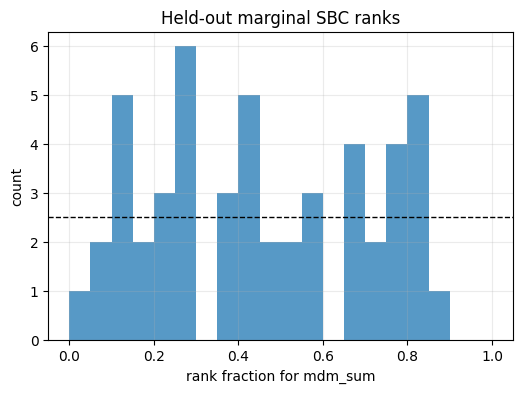

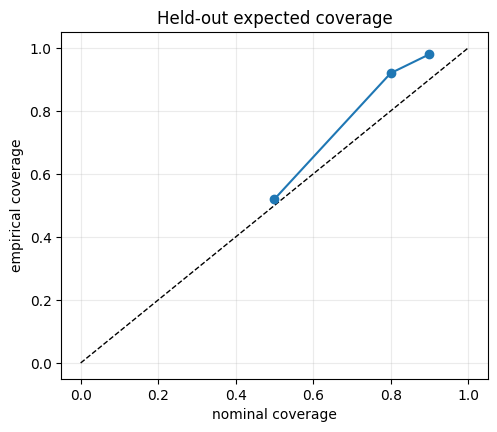

In [8]:

plot_sbi_theta_posterior(
    theta_prior=theta,
    posterior_samples=sbi_result["samples"],
    title=f"SBI posterior for {TARGET}",
)
plt.show()

# Approximate posterior predictive check.
x_pred = sbi_result["x_predictive_samples"]
n_features = len(ACTIVE_FEATURES)
fig, axes = plt.subplots(1, n_features, figsize=(5 * n_features, 3.8), constrained_layout=True)
if n_features == 1:
    axes = [axes]

for j, name in enumerate(ACTIVE_FEATURES):
    ax = axes[j]
    ax.hist(x_pred[:, j], bins=30, alpha=0.75)
    ax.axvline(x_obs[j], linestyle="--", linewidth=2)
    pct = sbi_result["x_obs_predictive_percentile"][name]
    ax.set_title(f"{FEATURE_INFO[name]['label']}\nobs percentile ~ {pct:.3f}")
    ax.set_xlabel(name)
    ax.set_ylabel("count")
    ax.grid(alpha=0.25)

fig.suptitle("Approximate posterior predictive distributions in feature space", y=1.05, fontsize=14)
plt.show()

# SBC-like rank histogram
if "sbc_ranks" in fit["diagnostics"]:
    plot_sbc_rank_hist(
        fit["diagnostics"]["sbc_ranks"],
        num_posterior_samples=fit["diagnostics"]["sbc_summary"]["num_posterior_samples"],
        parameter_label=TARGET,
        title="Held-out marginal SBC ranks",
    )
    plt.show()

# Expected coverage
coverage = fit["diagnostics"].get("expected_coverage_1d")
if coverage is not None and coverage.get("num_eval", 0) > 0:
    plot_expected_coverage(coverage, title="Held-out expected coverage")
    plt.show()



## 8) How to interpret the result

Use this checklist when reading the output:

### A. Posterior summary
- `median`, `q16`, `q84` summarize the inferred range of the hidden quantity
- if `TARGET_LOG10 = True`, convert back with `10 ** value` for a linear-scale interpretation

### B. Support check
- `n_outside = 0` is good: the observation is inside the catalogue support
- `nearest_distance` small means the observation has nearby analogue pairs and is not an extrapolation case

### C. Posterior predictive percentiles
- values near 0.5 mean the observed feature is typical under the approximate predictive
- values near 0 or 1 mean that feature may be harder to match and may be driving the posterior more strongly

### D. Calibration plots
- SBC rank histogram should be roughly flat, not strongly U-shaped or hump-shaped
- expected coverage should be reasonably close to the diagonal

These diagnostics do **not** prove the posterior is correct, but they help catch obvious failures.



## 9) Suggested experiments

Once this notebook works end-to-end, try these small variations:

1. **Change the active feature set**
   - `["r_kpc", "v_r"]`
   - `["r_kpc", "v_r", "v_t"]`
   - add mass or star-formation proxies if available

2. **Change the observation**
   - update `X_OBS_OVERRIDE`
   - rerun only from the feature-configuration cell downward

3. **Change the target**
   - total mass
   - mass ratio
   - orbital-energy proxy
   - environment measure

4. **Compare methods**
   - run KDE / GMM on the same `X`, `theta`, `x_obs`
   - compare posterior medians, intervals, and diagnostics

That is the cleanest way to connect this notebook back to the presentation claim that the project can become a reusable tool for future observations.
